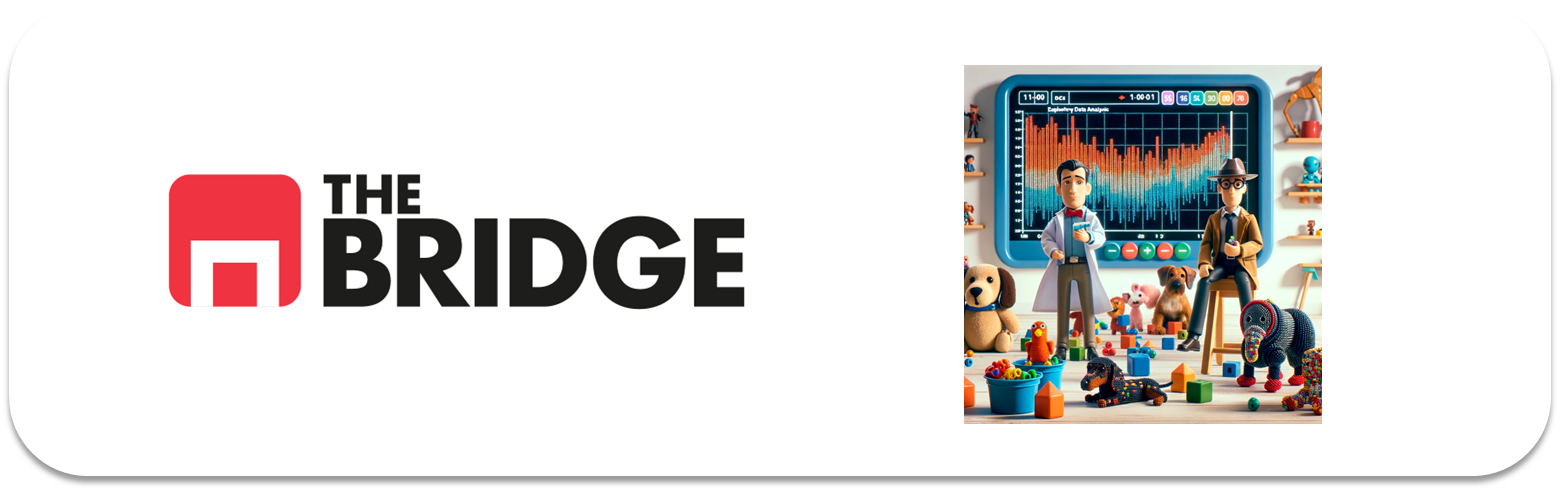

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [151]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [152]:
df_titanic = pd.read_csv('./data/titanic.csv')


In [153]:
df_titanic.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [154]:
df_titanic.drop(columns=["deck", "survived","pclass", "embarked"], inplace=True)

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [155]:
df_titanic["family_members"] = df_titanic["parch"] + df_titanic["sibsp"]

In [156]:
df_titanic.drop(columns=["parch", "sibsp"], inplace=True)


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [157]:
df_titanic['embark_town'] = df_titanic['embark_town'].fillna(df_titanic['embark_town'].mode()[0])

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [158]:
df_titanic['age'] = df_titanic['age'].fillna(df_titanic.groupby("who")["age"].transform("mean"))


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [159]:
# Importamos las funciones para la representación gráfica
import bootcampviztools as func

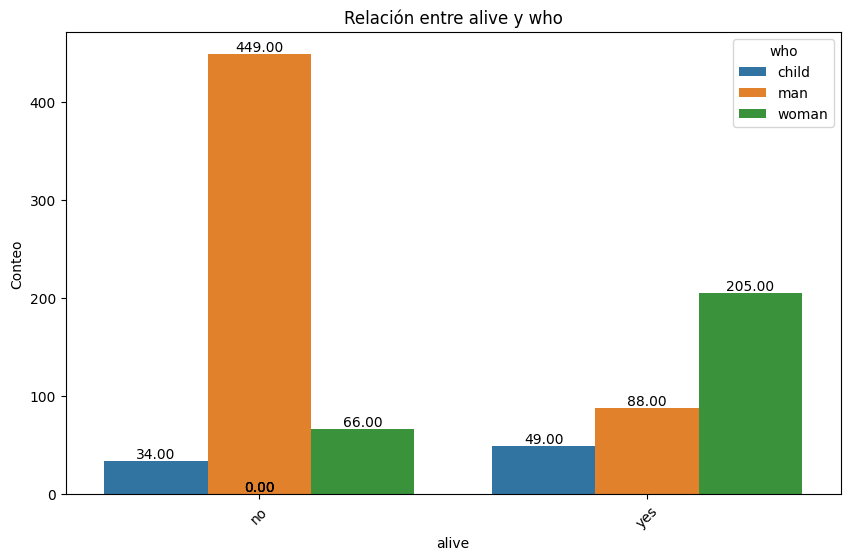

In [160]:
# 1 En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños?

func.plot_categorical_relationship_fin(df_titanic, "alive", "who", show_values=True)

**Vemos como en términos absolutos, sobrevivieron mas mujeres que hombres o niños**

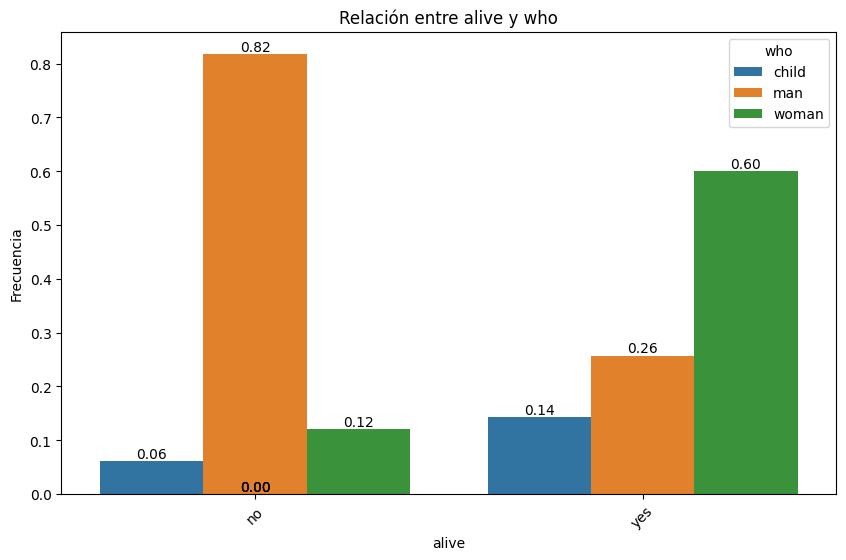

In [161]:
# 1 ¿Y en términos relativos?
func.plot_categorical_relationship_fin(df_titanic, "alive", "who", relative_freq=True, show_values=True)

**El 82% de los pasajeros que murieron eran hombres y el 60% de los pasajeros que sobrevivieron eran mujeres**

**Gráficamente vemos como la supervivencia depende del sexo, aplicaremos el test Chi-Cuadrado (χ²)**

In [162]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['who'])

tabla_contingencia

who,child,man,woman
alive,,,
no,34,449,66
yes,49,88,205


In [163]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


**vemos como efectivamente hay una dependencia entre la variable alive y who ya que el p-valor es menor a 0.05**

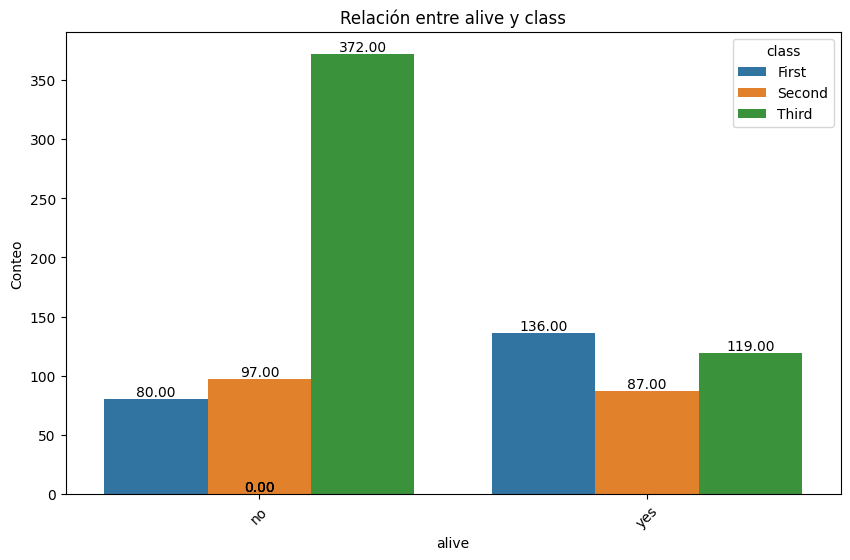

In [164]:
#2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? 
#¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?
func.plot_categorical_relationship_fin(df_titanic, "alive", "class", show_values=True)



**en términos absolutos sobrevivieron más personas de clase primera**

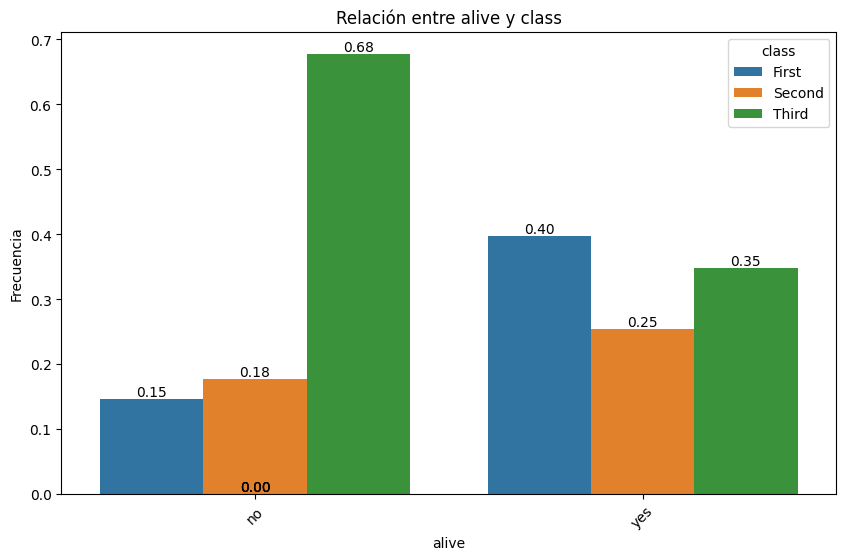

In [165]:
func.plot_categorical_relationship_fin(df_titanic, "alive", "class", relative_freq=True, show_values=True)

**en términos relativos, el 40% de los supervivientes eran de primera clase**

In [166]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['class'])

tabla_contingencia

class,First,Second,Third
alive,,,
no,80,97,372
yes,136,87,119


In [167]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


**claramente, como ya suponíamos las variables alive y class son dependientes pq p-value es menor a 0.05**

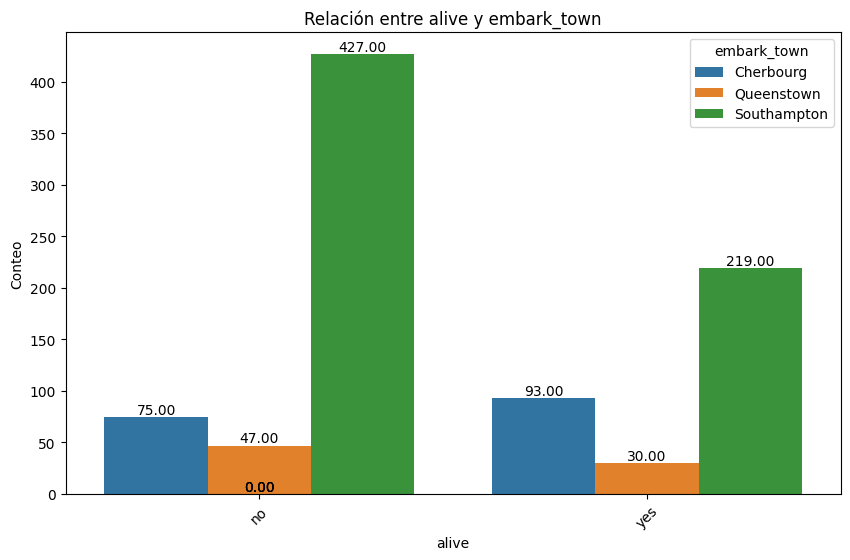

In [168]:
# 3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? 
# ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?
func.plot_categorical_relationship_fin(df_titanic, "alive", "embark_town", show_values=True)


**sobrevivieron más pasajeros de southampton, también es verdad que la mayoría de pasajeros embarcaron en esta ciudad**

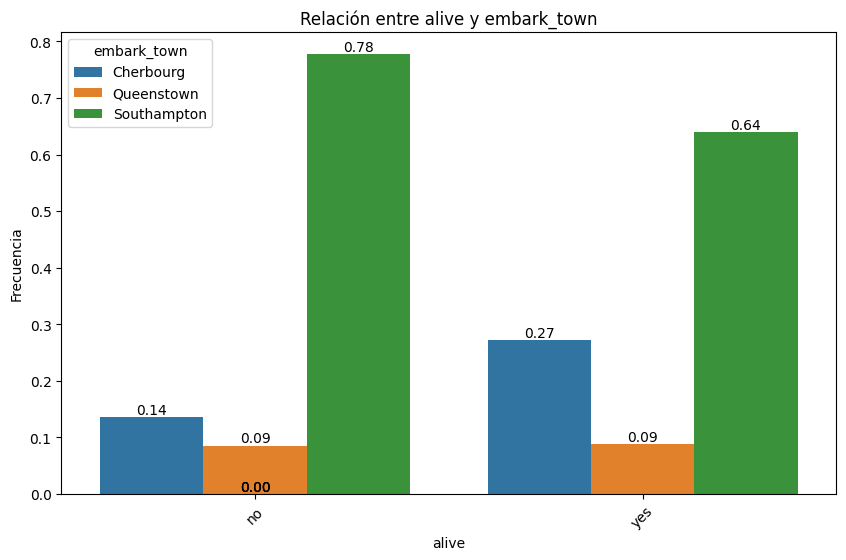

In [169]:
func.plot_categorical_relationship_fin(df_titanic, "alive", "embark_town", relative_freq=True, show_values=True)

**porcentualmente vemos lo mismo**

In [170]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['embark_town'])

tabla_contingencia

embark_town,Cherbourg,Queenstown,Southampton
alive,,,
no,75,47,427
yes,93,30,219


In [171]:
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]


**estadísticamente vemos como alive y embark_town son variables dependientes**

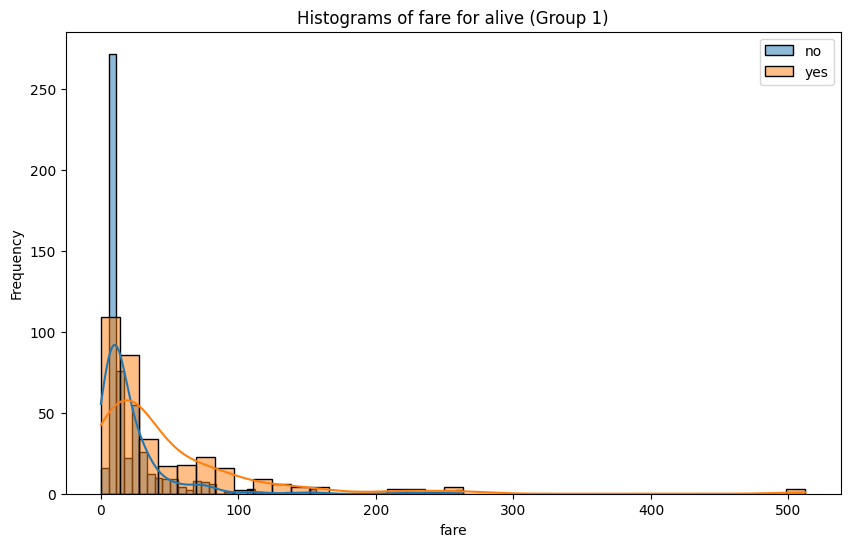

In [172]:
# 4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?
func.plot_grouped_histograms(df_titanic, cat_col="alive",num_col="fare", group_size= 2)

**Parecería que cuanto más barato era el pasaje hubiera menos probabilidades de sobrevivir, lo que claramente nos indica que 
hay una dependencia entre el precio del fare y la supervivencia**

**Vamos a ver si podemos afirmarlo estadísticamente.**

**No podemos usar el test t-Student para ver la relación entre alive y fare ya que la distribución de alive 
no se distribuye como una normal, aplicaremos la prueba U de Mann-Whitney**

In [173]:

from scipy.stats import mannwhitneyu 

In [174]:
# separamos el precio según alive
grupo_a = df_titanic.loc[df_titanic.alive == "yes"]["fare"]
grupo_b = df_titanic.loc[df_titanic.alive == "no"]["fare"]

In [175]:
# Aplicando la prueba U de Mann-Whitney:
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


**como el value p es menor que 0.05 podemos afirmar que hay relación entre alive y fare**

In [176]:
# 5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? 
# ¿Qué ocurrió con la persona que más dinero se dejó?

df_titanic[df_titanic["fare"] == 0]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0.0,Third,man,True,Southampton,yes,True,0
277,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0.0,Third,man,True,Southampton,no,True,0
413,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
466,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
481,male,33.173123,0.0,Second,man,True,Southampton,no,True,0
597,male,49.000000,0.0,Third,man,True,Southampton,no,True,0
633,male,33.173123,0.0,First,man,True,Southampton,no,True,0


**vemos que los pasajeros que no pagaron billete eran hombres que viajaban solos, suponemos que formarían parte de la tripulación**

**Aunque cabe destacar que había varios que viajaban en primera clase, seguramente pq eran oficiales de rango superior**

In [177]:
df_titanic[df_titanic["fare"] == df_titanic["fare"].max()]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
258,female,35.0,512.3292,First,woman,False,Cherbourg,yes,True,0
679,male,36.0,512.3292,First,man,True,Cherbourg,yes,False,1
737,male,35.0,512.3292,First,man,True,Cherbourg,yes,True,0


**estas tres personas son las que pagaron el pasaje más caro**

**vemos como sobrevivieron y que eran de primera clase**

**es coherente con lo que hemos visto sobre la relación entre clase y precio pasaje respecto a la supervivencia**

Sobrevivieron: 



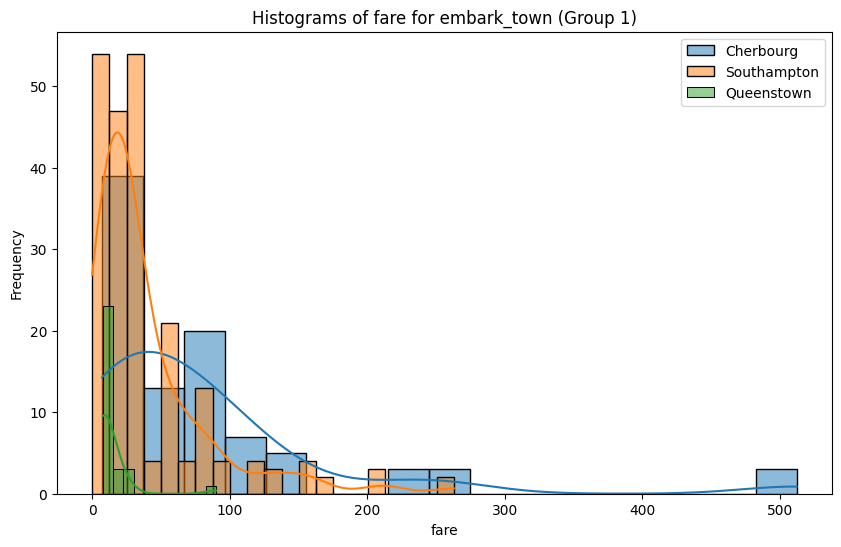

In [178]:
# 6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. 
# No necesitas aplicar ningún test, muestralo numérica o visualmente.

# Dividimos el dataset en dos según la vbariable binaria alive
df_alive = df_titanic[df_titanic["alive"] == 'yes']
df_dead = df_titanic[df_titanic["alive"] == 'no']

# Comparamos la ciudad de embarque y el fare
print(f"Sobrevivieron: \n")
func.plot_grouped_histograms(df_alive, "embark_town","fare", group_size= 3)


**Independientemente de donde embarcaron, la mayoría de los que sobrevivieron paragaron por el billete menos de 150**

No sobrevivieron: 



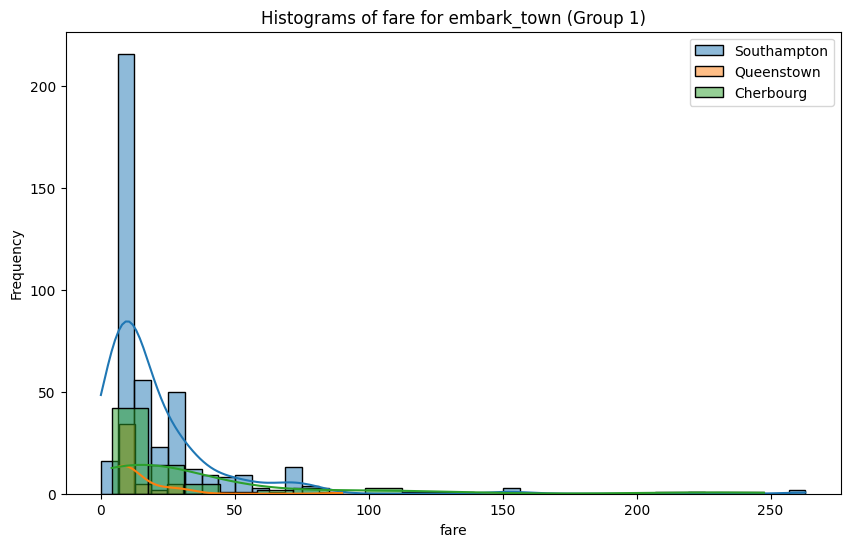

In [179]:
# Comparamos la ciudad de embarque y el fare
print(f"No sobrevivieron: \n")
func.plot_grouped_histograms(df_dead, "embark_town","fare", group_size= 3)

**Independientemente de donde embarcaron, la mayoría de los que NO sobrevivieron paragaron por el billete menos de 100**


Sobrevivieron: 



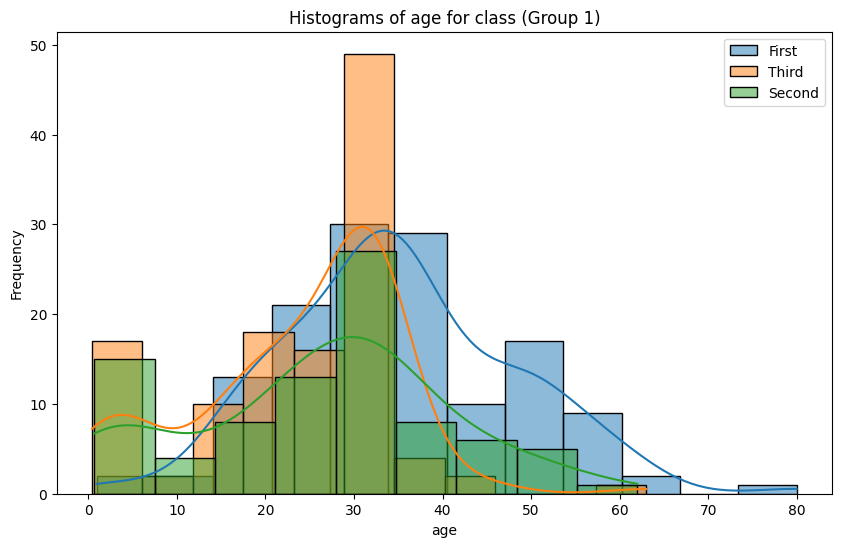

In [180]:
# 7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. 
# ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

# Sobre el dataframe de los supervivientes estudiamos la relación entre clase y edad
print(f"Sobrevivieron: \n")
func.plot_grouped_histograms(df_alive, "class","age", group_size= 3)


**En términos absolutos, sobrevivieron más los pasajeros de 3ª Clase de 30 años**


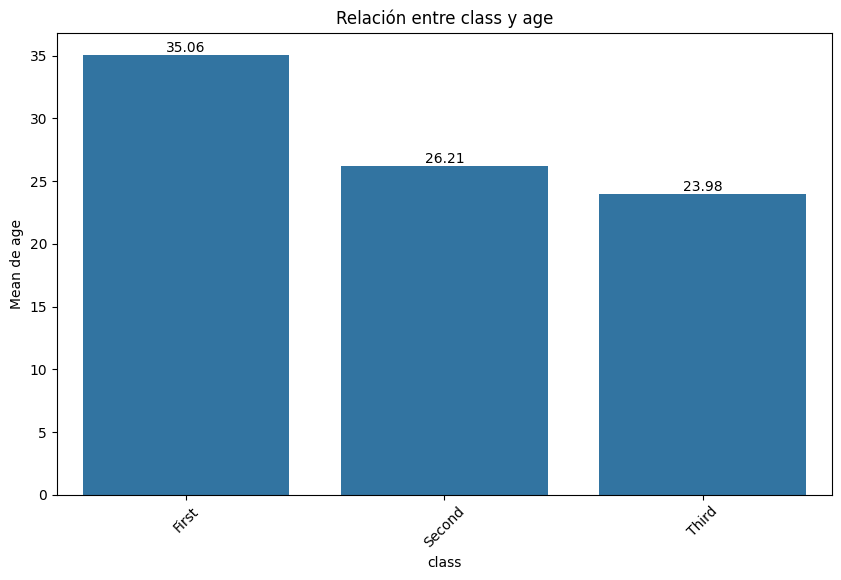

In [181]:
# En términos relativos
func.plot_categorical_numerical_relationship(df_alive, "class", "age", show_values=True)


**en términos relativos, sobrevivieron más pasajeros de 1ª Clase y de uns 35 años**


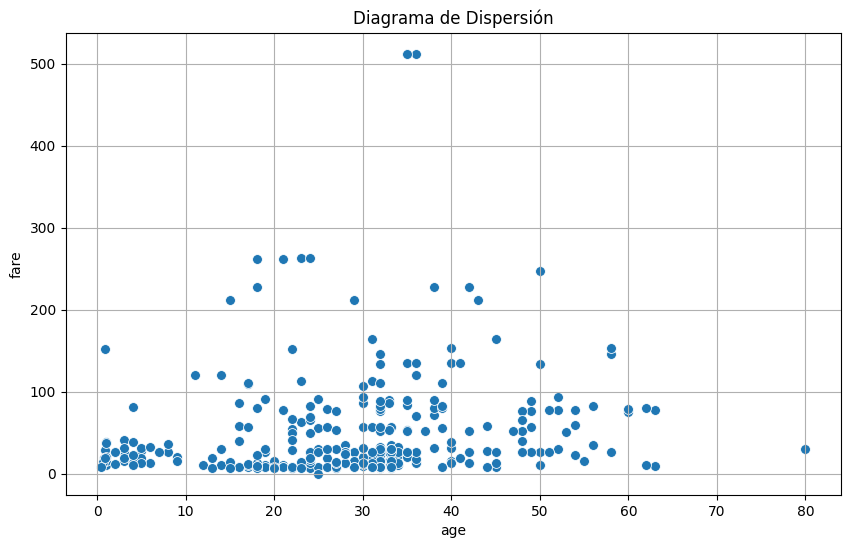

In [182]:
# 8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. 
# ¿Qué puedes decir al respecto?
func.grafico_dispersion_con_correlacion(df_alive,"age","fare", 50)

In [183]:
corr_matrix = df_alive[["age", "fare"]].corr(numeric_only= True) # Si no lo pones y tienes variables tipo texto, fallará7
corr_matrix

,age,fare
age,1.000000,0.144418
fare,0.144418,1.000000


**Vemos como respecto a los supervivientes, hay poca correlación entre las edades y el precio del billete**

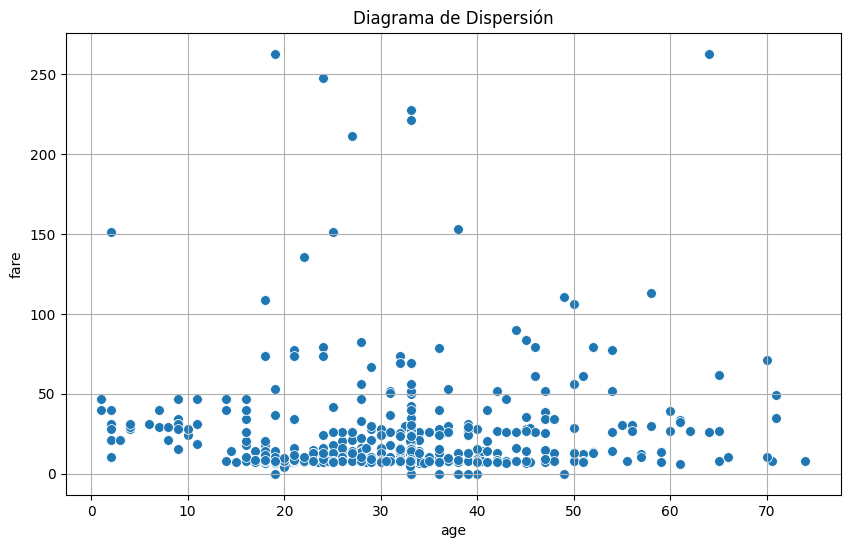

In [184]:
func.grafico_dispersion_con_correlacion(df_dead,"age","fare", 50)

In [185]:
corr_matrix = df_dead[["age", "fare"]].corr(numeric_only= True) # Si no lo pones y tienes variables tipo texto, fallará7
corr_matrix

,age,fare
age,1.000000,0.062993
fare,0.062993,1.000000


**Vemos como respecto a los NO supervivientes, todavía hay menos correlación entre las edades y el precio del billete**

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?